# Imports

In [50]:
from pathlib import Path
import math
import os
import sys

import torch
from torch import Tensor
from torchvision.transforms.functional import gaussian_blur
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.path.abspath(os.pardir))
sys.path.append(str(PROJECT_ROOT))

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders, get_img_from_loader
from utils.uncertainty import mc_predict, quantify_uncertainties

from models.lenet import Net as LeNet
from config import Config

In [4]:
torch.manual_seed(42)

config = Config()
device = config.device

# Prepare data
_, _, test_loader = get_dataloaders(
    data_dir=str(PROJECT_ROOT / 'data'),
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset='EMNIST',
    dataset_kwargs={"split": "letters"},
)

# Model
emnist_model = LeNet(
    prior_sigma1=math.exp(-0.8470609173270909),
    prior_sigma2=math.exp(-7.293222293379696),
    prior_pi=0.44622172885322486,
    num_classes=26,
    rho_init=-5.724956071835678,
).to(device)

emnist_checkpoint = (
    PROJECT_ROOT
    / "checkpoints"
    / "lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1"
    / "lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1.pth"
)

# Load weights
load_checkpoint(emnist_model, None, str(emnist_checkpoint), device)

100%|██████████| 562M/562M [00:02<00:00, 222MB/s]


[checkpoint] Loaded from /content/bayes_nn/checkpoints/emnist_letters/bcnn_vi_lenet_emnist_20260317.pth, starting at epoch 61


61

In [5]:
T = 10
kernel_sizes = [1, 3, 5, 7, 9]



# Plots

In [35]:
def plot_blurred_image_with_uncertainty_and_probability(img: Tensor, label: int, kernel_sizes: list[int]):
    blurred_images = [gaussian_blur(img, ks) for ks in kernel_sizes]
    blurred_mc_preds = [mc_predict(emnist_model, blurred_img.unsqueeze(0), T) for blurred_img in blurred_images]
    blurred_uncertainties = [quantify_uncertainties(mc_preds) for mc_preds in blurred_mc_preds]

    fig, axes = plt.subplots(
        3, len(kernel_sizes),
        figsize=(16, 9),
        gridspec_kw={
            'height_ratios': [1.5, 1, 1],
        },
        sharey='row'
    )

    for i, (ks, blurred_img, mc_preds) in enumerate(zip(kernel_sizes, blurred_images, blurred_mc_preds)):
        axes[0, i].imshow(blurred_img.squeeze().cpu(), cmap='gray')
        axes[0, i].set_title(f"""
    Kernel Size = {ks}
    Prediction: {mc_preds.mean(0).squeeze().argmax()},  True: {label}
        """)
        axes[0, i].axis("off")

    for i, (_, alea, epis) in enumerate(blurred_uncertainties):
        uncertainties = {
            "AU": alea.squeeze().diag().cpu().numpy(),
            "EU": epis.squeeze().diag().cpu().numpy(),
        }

        bottom = np.zeros_like(next(iter(uncertainties.values())))
        for u_type, values in uncertainties.items():
            axes[1, i].bar(range(len(bottom)), values, bottom=bottom, label=u_type)
            bottom += values

        axes[1, i].set_xticks(range(0, len(bottom)))
        axes[1, i].set_xticklabels([chr(ord('@')+(i+1)) for i in range(len(bottom))])
        axes[1, 0].set_ylabel('Uncertainty')
        axes[1, i].legend(loc="upper right")

    for i, mc_preds in enumerate(blurred_mc_preds):
        mean_probs = mc_preds.mean(0).squeeze()
        axes[2, i].set_ylim(0, 1)
        axes[2, i].bar(range(len(mean_probs)), mean_probs.cpu().numpy())
        axes[2, i].set_xticks(range(len(mean_probs)))
        axes[2, i].set_xticklabels([chr(ord('@')+(i+1)) for i in range(len(mean_probs))])
        axes[2, i].set_xlabel('Class')
        axes[2, 0].set_ylabel('Probability')

    plt.tight_layout()
    plt.show()

Random batch index: 534, image index: 6


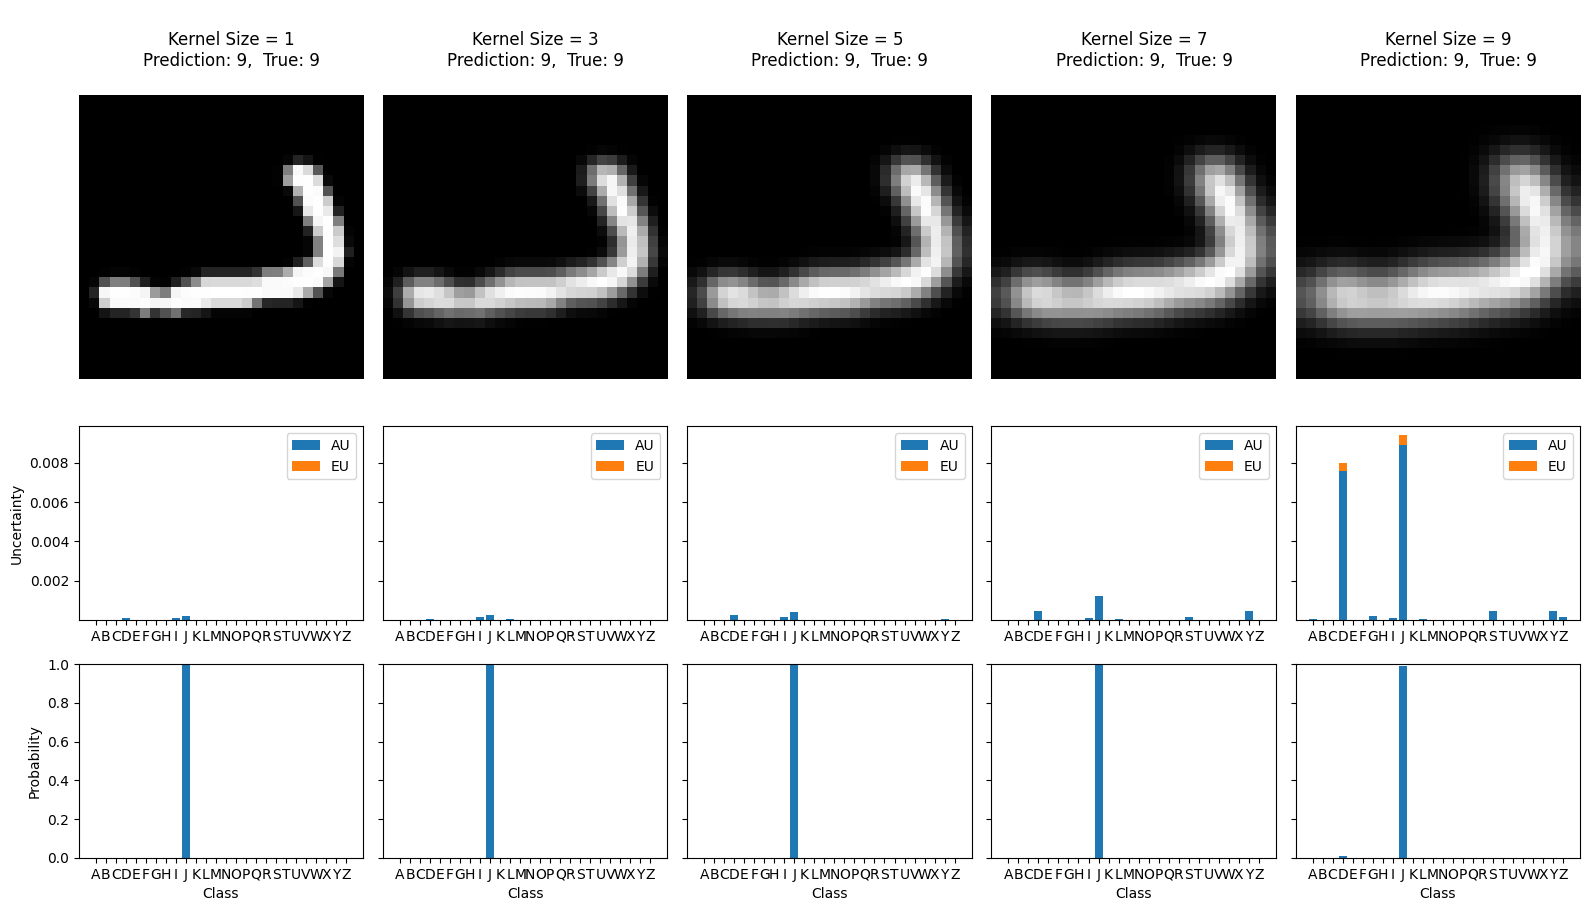

In [36]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=device)
plot_blurred_image_with_uncertainty_and_probability(img, label, kernel_sizes)

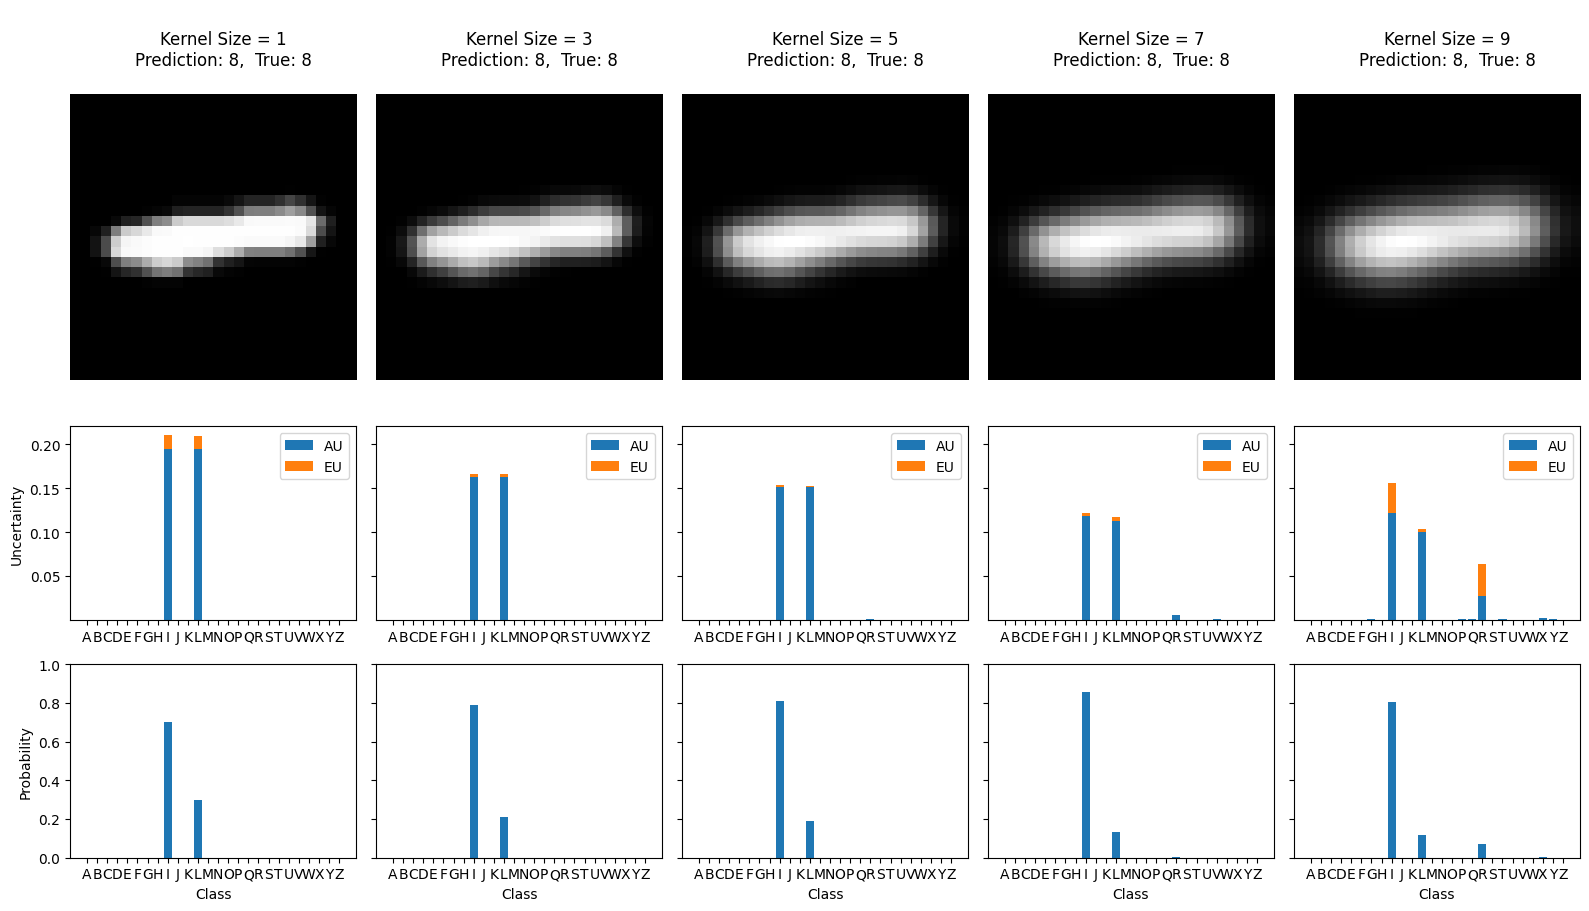

In [37]:
img, label = get_img_from_loader(test_loader, batch_idx=489, img_idx=11, device=device)
plot_blurred_image_with_uncertainty_and_probability(img, label, kernel_sizes)

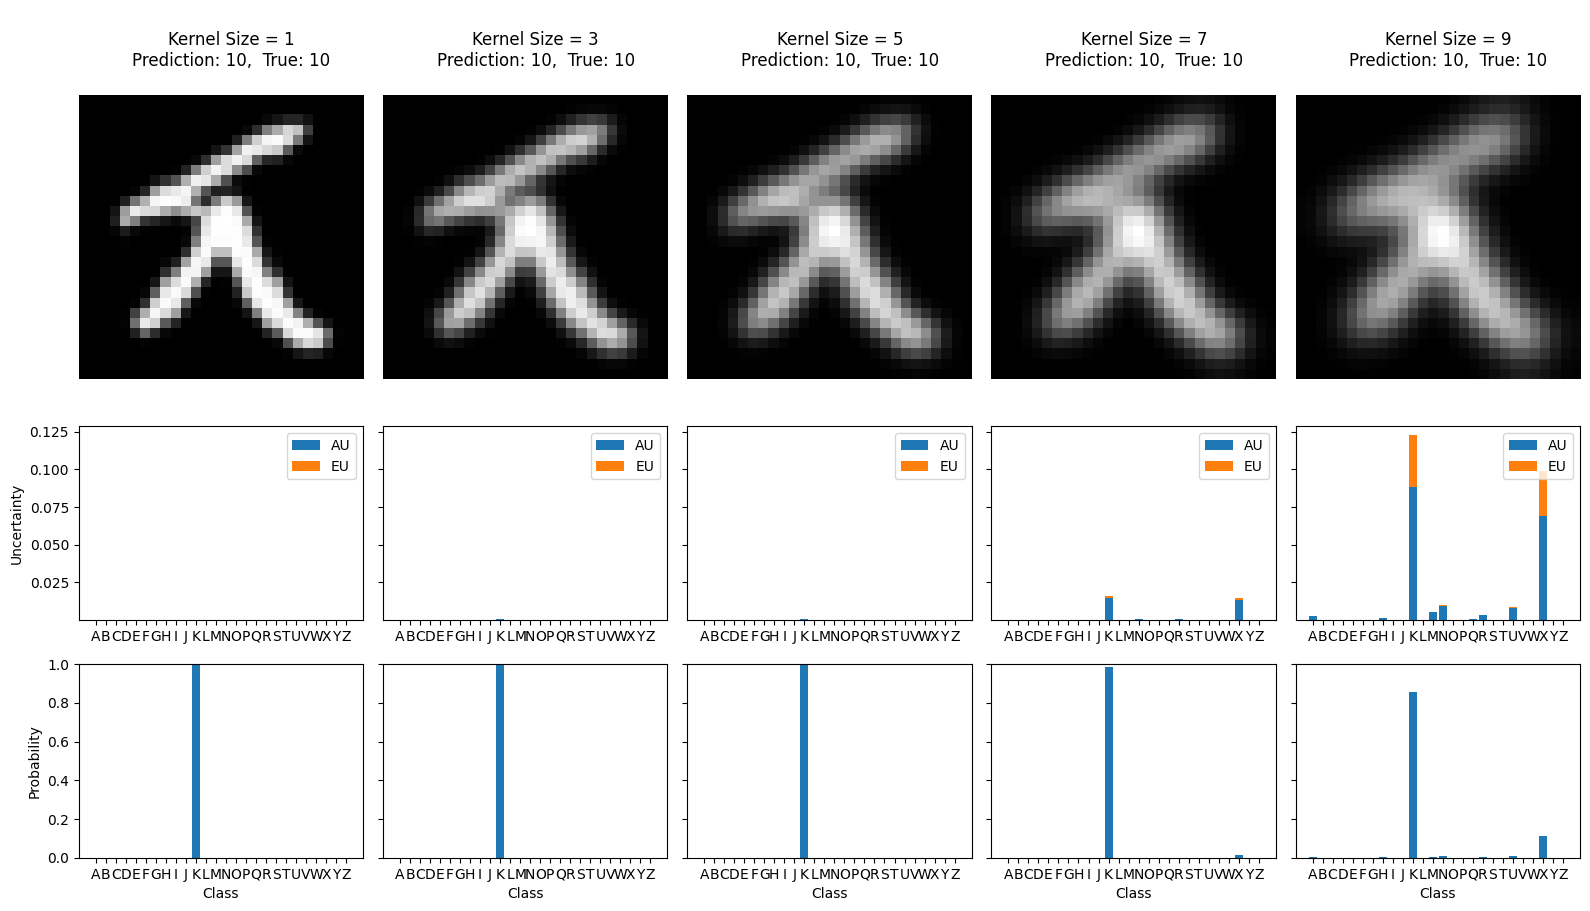

In [38]:
img, label = get_img_from_loader(test_loader, batch_idx=614, img_idx=12, device=device)
plot_blurred_image_with_uncertainty_and_probability(img, label, kernel_sizes)

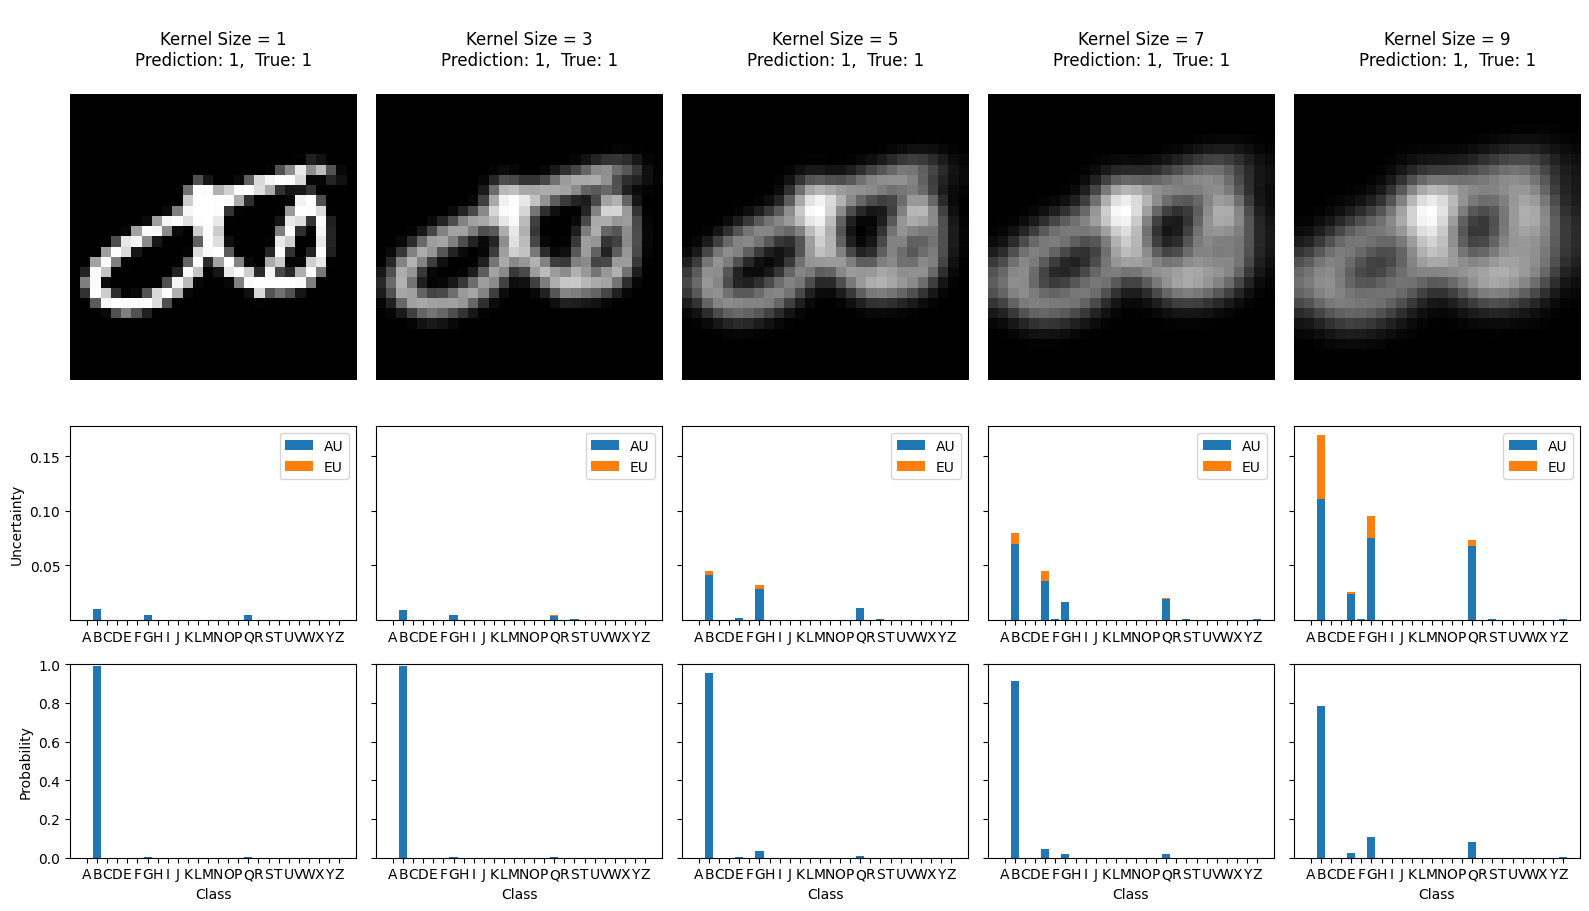

In [39]:
img, label = get_img_from_loader(test_loader, batch_idx=101, img_idx=4, device=device)
plot_blurred_image_with_uncertainty_and_probability(img, label, kernel_sizes)

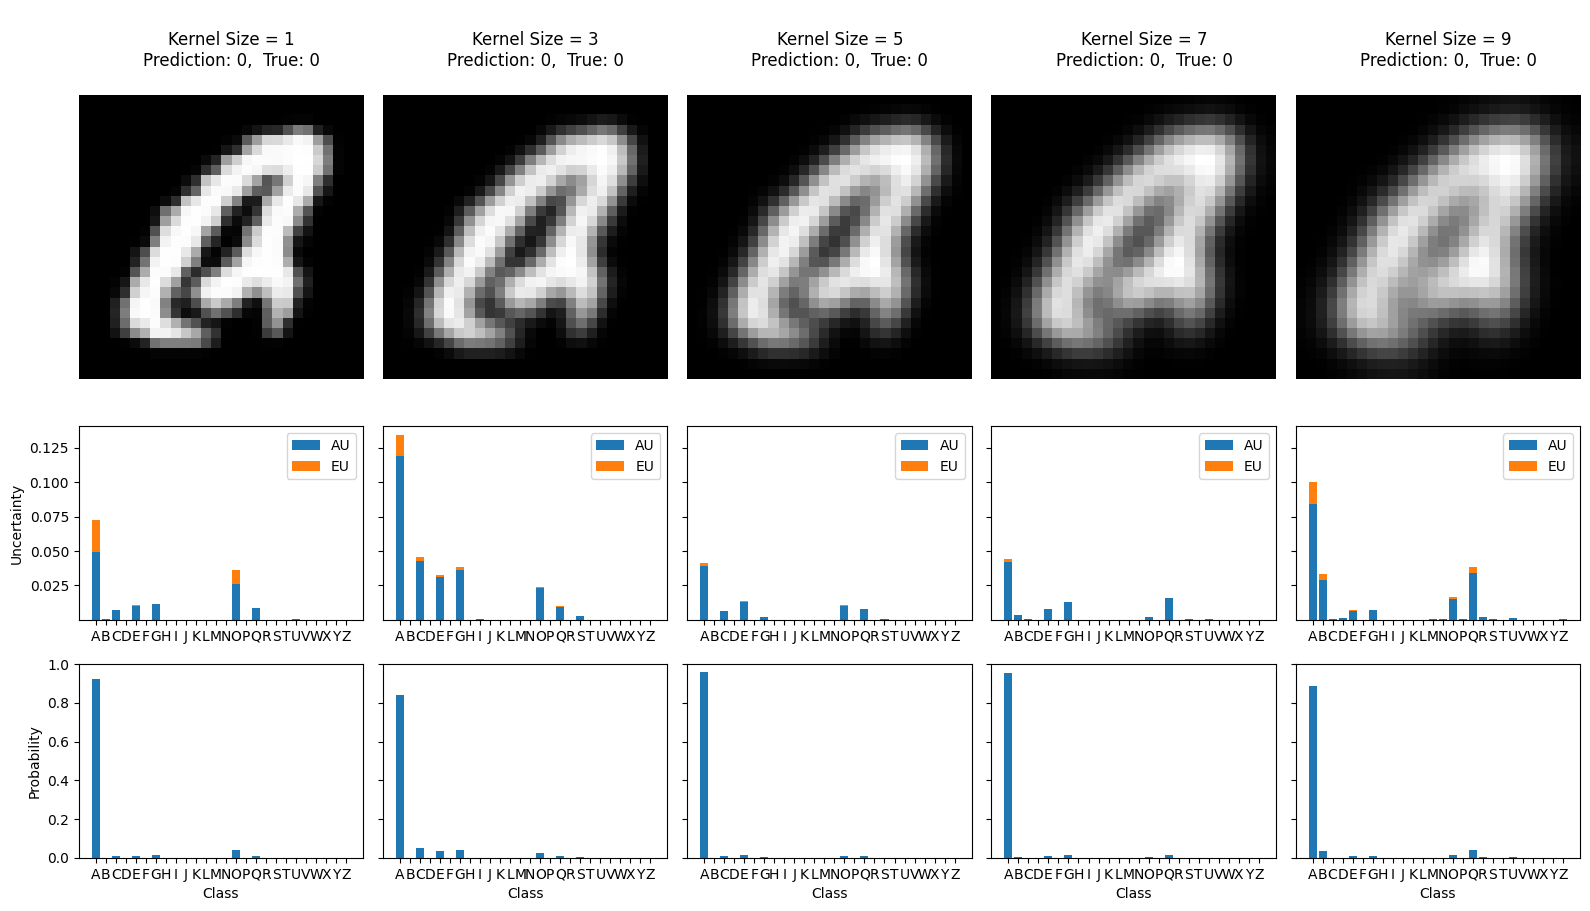

In [40]:
img, label = get_img_from_loader(test_loader, batch_idx=29, img_idx=3, device=device)
plot_blurred_image_with_uncertainty_and_probability(img, label, kernel_sizes)